In [1]:
import gymnasium as gym

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [4]:
class ValueNetwork(nn.Module):

    def __init__(self, n_observations, n_actions, n_hidden):
        super(ValueNetwork, self).__init__()
        self.layer1 = nn.Linear(n_observations + n_actions, n_hidden)
        self.layer2 = nn.Linear(n_hidden, 1)

    # Called with either one element to determine next action, or a batch
    # during optimization.
    def forward(self, states, actions):
        x = torch.cat([states, actions], dim=1)
        x = F.relu(self.layer1(x))
        return self.layer2(x)

In [5]:
class PolicyNetwork(nn.Module):
    def __init__(self, n_states, n_hidden, n_actions, max_action):
        super(PolicyNetwork, self).__init__()
        # Using an Embedding or One-Hot input for discrete states
        self.affine = nn.Linear(n_states, n_hidden)
        self.action_head = nn.Linear(n_hidden, n_actions)
        self.max_action = max_action

    def forward(self, x):
        # x is state index; convert to one-hot for the network
        x = F.relu(self.affine(x))
        return torch.tanh(self.action_head(x)) * self.max_action

In [6]:
env=gym.make('Pendulum-v1')

n_states = env.observation_space.shape[0]
n_actions = env.action_space.shape[0]

possible_actions = np.linspace(0, n_actions-1, n_actions)
ALPHA = 1e-4
GAMMA = 0.9
BATCH_SIZE = 32
EPSILON = 0.01
N_EPISODES = 500
TAU = 0.05
MEM_SIZE=2000

n_hidden = 32

In [7]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [35]:
class TD3():
    def __init__(self):
        # Define the critic
        self.critic_policy = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target = ValueNetwork(n_states, n_actions, n_hidden).to(device)
        self.critic_target.load_state_dict(self.critic_policy.state_dict())
        self.critic_optimizer = optim.AdamW(self.critic_policy.parameters(), lr=ALPHA, amsgrad=True)
        self.memory = ReplayMemory(MEM_SIZE)

        # Define the actor
        max_action = float(env.action_space.high[0])
        self.actor_policy = PolicyNetwork(n_states, n_hidden, n_actions,max_action)
        self.actor_target = PolicyNetwork(n_states, n_hidden, n_actions,max_action)
        self.actor_target.load_state_dict(self.actor_policy.state_dict()) 
        self.actor_optimizer = optim.AdamW(self.actor_policy.parameters(), lr=ALPHA, amsgrad=True)
        
        self.gamma = GAMMA

    def learn_actor(self, state_batch):
        self.actor_optimizer.zero_grad()
        
        # 1. Ask CURRENT actor what it would do in these states
        # 2. Ask CURRENT critic how good those actions are
        # We use -mean because we want to maximize the Q-value
        actions_pred = self.actor_policy(state_batch)

        noisy_action_pred = actions_pred + torch.tensor((np.random.normal(0, 0.1, size=n_actions)), dtype=torch.float32, device=device)
        noisy_action_pred = torch.clip(noisy_action_pred, -self.actor_policy.max_action, self.actor_policy.max_action)
        actor_loss = -self.critic_policy(state_batch, noisy_action_pred).mean()
        
        actor_loss.backward()
        self.actor_optimizer.step()
    
        # Soft update of target actor
        for target_param, param in zip(self.actor_target.parameters(), self.actor_policy.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)
    
    def learn_critic(self, state_batch, action_batch, reward_batch, non_final_mask, non_final_next_states):
        # Q(s, a) from online critic
        current_q_values = self.critic_policy(state_batch, action_batch)
        
        # Target Q calculation: r + gamma * Q_target(s', actor_target(s'))
        next_q_values = torch.zeros(BATCH_SIZE, device=device)
        with torch.no_grad():
            if non_final_mask.any():
                target_actions = self.actor_target(non_final_next_states)
                next_q_values[non_final_mask] = self.critic_target(non_final_next_states, target_actions).squeeze()
                    
        expected_q_values = (next_q_values * self.gamma) + reward_batch
        
        # Compute loss (ensuring both are [Batch, 1])
        criterion = nn.SmoothL1Loss()
        loss = criterion(current_q_values, expected_q_values.unsqueeze(1))
        
        self.critic_optimizer.zero_grad()
        loss.backward()
        self.critic_optimizer.step()
        
        # Soft update of target critic
        for target_param, param in zip(self.critic_target.parameters(), self.critic_policy.parameters()):
            target_param.data.copy_(target_param.data * (1.0 - TAU) + param.data * TAU)

In [36]:
def twin_delayed_ddpg(num_episodes=200):
    ddpg = TD3()
    rewards_list = []

    for e in range(num_episodes):
        obs, info = env.reset()
        # Convert to [1, 3] tensor immediately
        state = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        tot_reward = 0
        done = False
        
        while not done:
            # 1. Select Action
            with torch.no_grad():
                action = ddpg.actor_policy(state)
            
            # 2. Add Exploration Noise (Standard for DDPG)
            noisy_action = action.cpu().numpy()[0] + (np.random.normal(0, 0.1, size=n_actions))
            noisy_action = np.clip(noisy_action, -ddpg.actor_policy.max_action, ddpg.actor_policy.max_action)
            
            # 3. Step Environment
            state_next_obs, reward, terminated, truncated, _ = env.step(noisy_action)
            done = terminated or truncated
            tot_reward += reward

            # 4. Prepare tensors for Memory
            # Keep everything 2D for consistency
            action_tensor = torch.from_numpy(noisy_action).float().to(device).unsqueeze(0) # Convert directly from numpy to tensor, then add the batch dimension
            reward_tensor = torch.tensor([reward], dtype=torch.float32, device=device)
            state_next = torch.tensor(state_next_obs, dtype=torch.float32, device=device).unsqueeze(0) if not done else None

            ddpg.memory.push(state, action_tensor, state_next, reward_tensor)
            state = state_next 

            # 5. Optimize
            if len(ddpg.memory) >= BATCH_SIZE:
                transitions = ddpg.memory.sample(BATCH_SIZE)
                batch = Transition(*zip(*transitions))
                
                # Masks and batching
                non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), device=device, dtype=torch.bool)
                non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
                
                state_batch = torch.cat(batch.state)   # [32, 3]
                action_batch = torch.cat(batch.action) # [32, 1]
                reward_batch = torch.cat(batch.reward) # [32]
                
                ddpg.learn_critic(state_batch, action_batch, reward_batch, non_final_mask, non_final_next_states)
                ddpg.learn_actor(state_batch)

        rewards_list.append(tot_reward)
        if e % 10 == 0:
            print(f"Episode {e} | Reward: {tot_reward:.2f}")
            
    return rewards_list

In [37]:
rewards = twin_delayed_ddpg(num_episodes=N_EPISODES)

Episode 0 | Reward: -1366.91
Episode 10 | Reward: -1663.84
Episode 20 | Reward: -1608.98
Episode 30 | Reward: -1141.16
Episode 40 | Reward: -1811.15
Episode 50 | Reward: -1691.60
Episode 60 | Reward: -1589.01
Episode 70 | Reward: -1912.26
Episode 80 | Reward: -1586.07
Episode 90 | Reward: -1794.13
Episode 100 | Reward: -1299.79
Episode 110 | Reward: -1536.54
Episode 120 | Reward: -1515.96
Episode 130 | Reward: -1493.16
Episode 140 | Reward: -1235.54
Episode 150 | Reward: -1568.05
Episode 160 | Reward: -1527.01
Episode 170 | Reward: -1413.59
Episode 180 | Reward: -1489.83
Episode 190 | Reward: -1419.82
Episode 200 | Reward: -1503.12
Episode 210 | Reward: -1428.25
Episode 220 | Reward: -1490.86
Episode 230 | Reward: -1501.12
Episode 240 | Reward: -1565.37
Episode 250 | Reward: -1350.78
Episode 260 | Reward: -1564.75
Episode 270 | Reward: -1559.85
Episode 280 | Reward: -1546.25
Episode 290 | Reward: -1521.79
Episode 300 | Reward: -1528.97
Episode 310 | Reward: -1489.14
Episode 320 | Rewar

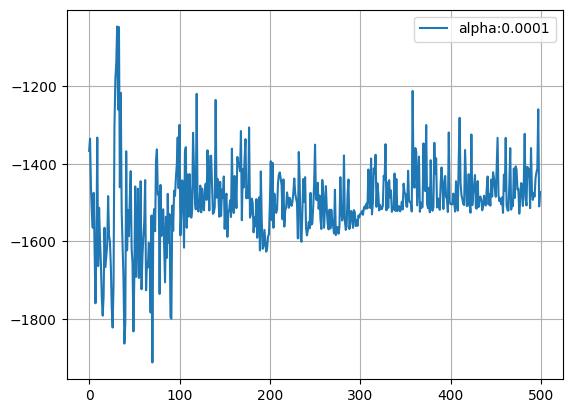

In [38]:
plt.grid()
plt.plot(rewards, label="alpha:"+str(round(ALPHA, 4)))
plt.legend()